In [206]:
#imports

#data structure
import pandas as pd

#model construction
import seaborn as sns
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.linear_model import LogisticRegression

#model evaluation
import sklearn.metrics as metrics
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score,f1_score, confusion_matrix, ConfusionMatrixDisplay


#machine learning
import sklearn.naive_bayes 
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier




In [207]:
#uploading data to dataframe
data = pd.read_csv("ACME-HappinessSurvey2020.csv")

In [208]:
#preliminary data exploration
data.head(5)

,Y,X1,X2,X3,X4,X5,X6
0,0,3,3,3,4,2,4
1,0,3,2,3,5,4,3
2,1,5,3,3,3,3,5
3,0,5,4,3,3,3,5
4,0,5,4,3,3,3,5


In [209]:
data.shape

(126, 7)

In [210]:
data['Y'].value_counts()

Y
1    69
0    57
Name: count, dtype: int64

Data has already been cleaned and prepared uniformly. The distribution of unhappy and happy customers is about even. We can continue onto model construction. Before using more advanced machine learning models, I would like to perform a binary logistic regression as results are more directly interpretable.

# Constructing the Model

In [211]:
y = data["Y"]
X = data[["X1", "X2", "X3", "X4", "X5", "X6"]]
X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=42)

reg_model = LogisticRegression(class_weight="balanced").fit(X_train,y_train)



In [212]:
print(X_test.shape)
print(X_train.shape)
print(y_test.shape)
print(y_train.shape)


(32, 6)
(94, 6)
(32,)
(94,)


In [213]:
y_pred = reg_model.predict(X_test)

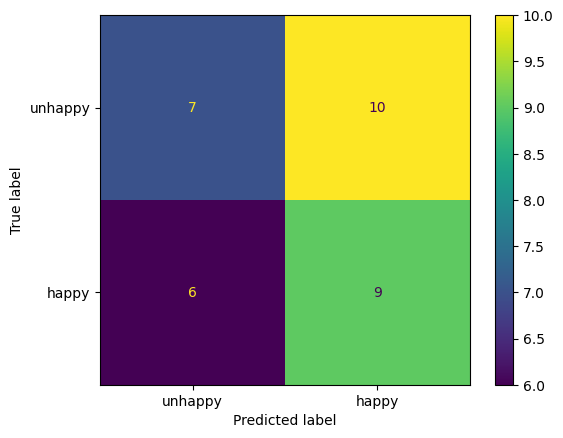

In [214]:
cm = metrics.confusion_matrix(y_test, y_pred, labels = reg_model.classes_)
disp = metrics.ConfusionMatrixDisplay(confusion_matrix = cm,display_labels=['unhappy', 'happy'])
disp.plot()

In [215]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.54      0.41      0.47        17
           1       0.47      0.60      0.53        15

    accuracy                           0.50        32
   macro avg       0.51      0.51      0.50        32
weighted avg       0.51      0.50      0.50        32



* Logistic regression has resulted in an accuracy score of .51
* This model performs as well as random choice... not ideal
* Next step is to move onto Machine learning models. I have chosen Gaussian since our dataset is small

# Gaussian NB

In [216]:
nb = sklearn.naive_bayes.GaussianNB() 
nb.fit(X_train,y_train)
y_pred_gnb = nb.predict(X_test)

In [217]:
print(classification_report(y_test, y_pred_gnb))

              precision    recall  f1-score   support

           0       0.40      0.24      0.30        17
           1       0.41      0.60      0.49        15

    accuracy                           0.41        32
   macro avg       0.40      0.42      0.39        32
weighted avg       0.40      0.41      0.39        32



Results remain unaccurate

# Random Forest Classifier

In [218]:

rf_model = RandomForestClassifier()

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 7, None],
    "min_samples_leaf": [1, 2, 4],
}
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1'
}
#Grid Search
grid_search = GridSearchCV(
    estimator=rf_model, 
    param_grid=param_grid,
    scoring=scoring, 
    refit='accuracy'
    )

In [219]:
#Fit
grid_search.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [220]:
grid_search.best_params_

{'max_depth': None, 'min_samples_leaf': 4, 'n_estimators': 100}

In [221]:
#Evaluate Model on Test Data
y_pred = grid_search.predict(X_test)
print("Test accuracy on Tuned Model:", accuracy_score(y_test, y_pred))

y_pred = rf_model.predict(X_test)
print("Test accuracy on Untuned Model:", accuracy_score(y_test, y_pred))

Test accuracy on Tuned Model: 0.46875
Test accuracy on Untuned Model: 0.5625


In [222]:
importance = pd.Series(
    grid_search.best_estimator_.feature_importances_,
    index=X.columns
)

print(importance.sort_values(ascending=False))

X1    0.295534
X2    0.179035
X6    0.143638
X4    0.138857
X5    0.124366
X3    0.118570
dtype: float64


The most important features are:
1. The order was received on time
2. The contents of the order are correct

# Regular Gradient Boosting

In [ ]:
gb = GradientBoostingClassifier(
   
    random_state=42
)

param_grid = {
    "n_estimators": [100, 150, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [2, 3],
    "subsample": [0.8, 1.0]
}

# Grid search
grid_search = GridSearchCV(
    estimator=gb,
    param_grid=param_grid,
    scoring="accuracy",
    n_jobs=-1,
)

# Fit
grid_search.fit(X_train, y_train)
gb.fit(X_train, y_train)
# Evaluate on test set
y_pred = grid_search.predict(X_test)
print("Test accuracy on Tuned Model:", accuracy_score(y_test, y_pred))
y_pred = gb.predict(X_test)
print("Test accuracy on Untuned Model:", accuracy_score(y_test, y_pred))

Test accuracy on Tuned Model: 0.5
Test accuracy on Untuned Model: 0.53125


# XGBoost Classifier

In [224]:

xgb_model = XGBClassifier(objective='binary:logistic', random_state=42, n_jobs=1)
param_grid = {
    "max_depth": [2, 3, 4],
    "min_child_weight": [1, 5, 10],
    "subsample": [0.7, 0.9],
    "colsample_bytree": [0.7, 0.9],
    "learning_rate": [0.01, 0.05, 0.1],
    "n_estimators": [200, 400, 600],
    "reg_alpha": [0, 1],
    "reg_lambda": [1, 10],
    "gamma": [0, 0.1]
}
# Grid search
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring=scoring,
    refit='accuracy',
    n_jobs=-1, 
    cv=5,
    verbose=2
)

#Fit
grid_search.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

Fitting 5 folds for each of 2592 candidates, totalling 12960 fits
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.01, max_depth=2, min_child_weight=1, n_estimators=200, reg_alpha=0, reg_lambda=1, subsample=0.7; total time=   0.1s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.01, max_depth=2, min_child_weight=1, n_estimators=200, reg_alpha=0, reg_lambda=1, subsample=0.7; total time=   0.1s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.01, max_depth=2, min_child_weight=1, n_estimators=200, reg_alpha=0, reg_lambda=1, subsample=0.7; total time=   0.1s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.01, max_depth=2, min_child_weight=1, n_estimators=200, reg_alpha=0, reg_lambda=1, subsample=0.7; total time=   0.1s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.01, max_depth=2, min_child_weight=1, n_estimators=200, reg_alpha=0, reg_lambda=1, subsample=0.7; total time=   0.1s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.01, max_depth=2, m

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [225]:
grid_search.best_params_

{'colsample_bytree': 0.9,
 'gamma': 0,
 'learning_rate': 0.01,
 'max_depth': 4,
 'min_child_weight': 1,
 'n_estimators': 200,
 'reg_alpha': 0,
 'reg_lambda': 1,
 'subsample': 0.7}

In [226]:
# Evaluate on test set
y_pred = grid_search.predict(X_test)
print("Test accuracy on Tuned Model:", accuracy_score(y_test, y_pred))

y_pred = xgb_model.predict(X_test)
print("Test accuracy on Untuned Model:", accuracy_score(y_test, y_pred))

Test accuracy on Tuned Model: 0.40625
Test accuracy on Untuned Model: 0.625


Oddly, my untuned models are performing better than my tuned models.